# [LAB 07] 추론통계 - 7. 사후검정 

## #01. 준비작업 

### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import *

# 사후 검정을 위한 라이브러리 
from pingouin import pairwise_tukey, pairwise_gameshowell

# 시각화 라이브러리 
from statannotations.Annotator import Annotator

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data('tree_weight')
origin.head()

📚 소나무 품종별 무게를 조사한 데이터 (출처: 방송통신대학교 통계학개론)


,weight,group
0,4.170,A
1,5.580,A
2,5.180,A
3,6.110,A
4,4.500,A


## #02. 사후검정 (post hoc)

### 1. 투키의 HSD

In [3]:
tukey_df = pairwise_tukey(data=origin, dv='weight', between='group') 
tukey_df

,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,A,B,5.032,4.661,0.371,0.279,1.331,0.391,0.510
1,A,C,5.032,5.526,-0.494,0.279,-1.772,0.198,-0.914
2,B,C,4.661,5.526,-0.865,0.279,-3.103,0.012,-1.289


### Games-Howell 검정 

In [4]:
gh_df = pairwise_gameshowell(origin, dv='weight', between='group') 
gh_df

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,A,B,5.032,4.661,0.371,0.311,1.191,16.524,0.475,0.510
1,A,C,5.032,5.526,-0.494,0.231,-2.134,16.786,0.113,-0.914
2,B,C,4.661,5.526,-0.865,0.287,-3.010,14.104,0.024,-1.289


## #03. 사후검정 결과 시각화

### 1. 그룹 순서 추출 

In [5]:
order = sorted(origin['group'].unique())
order 

['A', 'B', 'C']

### 2. 비교 대상 그룹 쌍 추출 

In [6]:
pairs = list(zip(tukey_df['A'], tukey_df['B']))
pairs

[('A', 'B'), ('A', 'C'), ('B', 'C')]

### 3. 각 그룹에 대응하는 p값 추출 

In [7]:
pvalues = list(tukey_df['p_tukey'])
pvalues

[0.39087114420210534, 0.1979959912995718, 0.012006423979493142]

### 4. 시각화 구현 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

A vs. B: Custom statistical test, P_val:3.909e-01
B vs. C: Custom statistical test, P_val:1.201e-02
A vs. C: Custom statistical test, P_val:1.980e-01


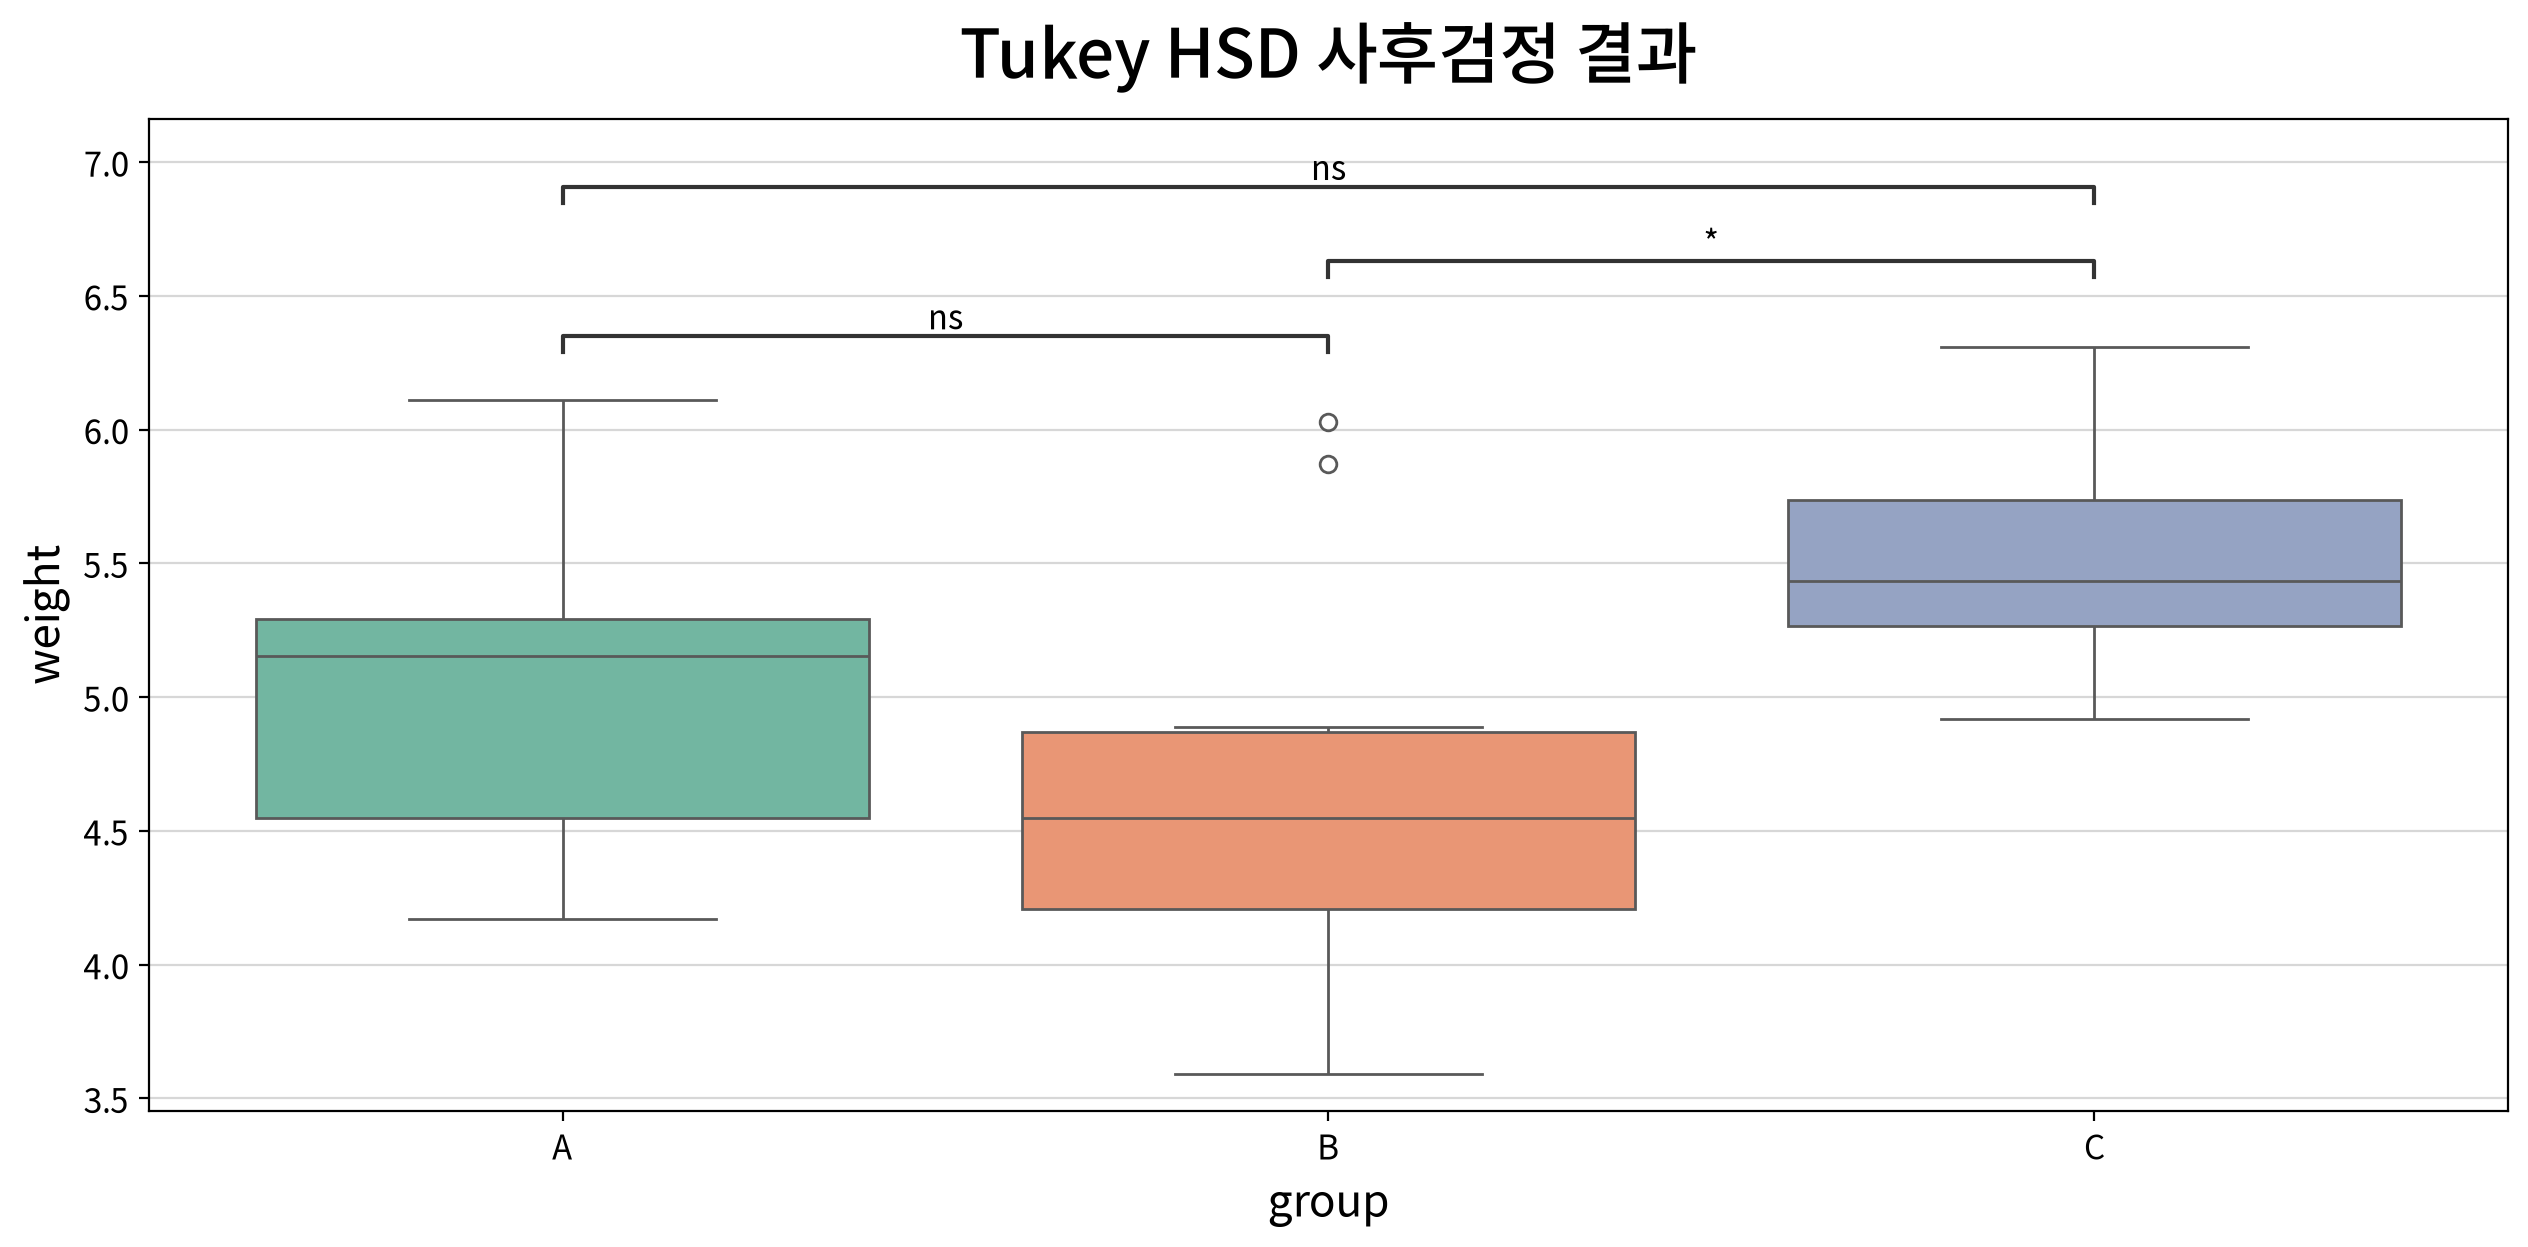

In [8]:
# 그래프 초기화 
fig, ax = my_plot.init(title="Tukey HSD 사후검정 결과", xlabel="group", 
                       ylabel="weight")

# my_plot.boxplot으로 그룹별 분포 시각화 
my_plot.boxplot(data=origin, x='group', y='weight', hue='group', 
                palette='Set2', order=order, ax=ax)

# Annotator로 그룹 간 유의성(p-value) 주석을 박스플롯 위에 추가 
annotator = Annotator(ax, pairs, data=origin, x='group', y='weight', order=order)

# Tukey 검정에서 구한 p값을 그래도 주입 
annotator.set_pvalues(pvalues)
annotator.annotate()

# my_plot.show로 그래프 출력 
my_plot.show()

## #04. 모듈화 기능 확인 

### 1. 사후검정 및 결과 시각화 일괄 처리 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

A vs. B: Custom statistical test, P_val:3.909e-01
B vs. C: Custom statistical test, P_val:1.201e-02
A vs. C: Custom statistical test, P_val:1.980e-01


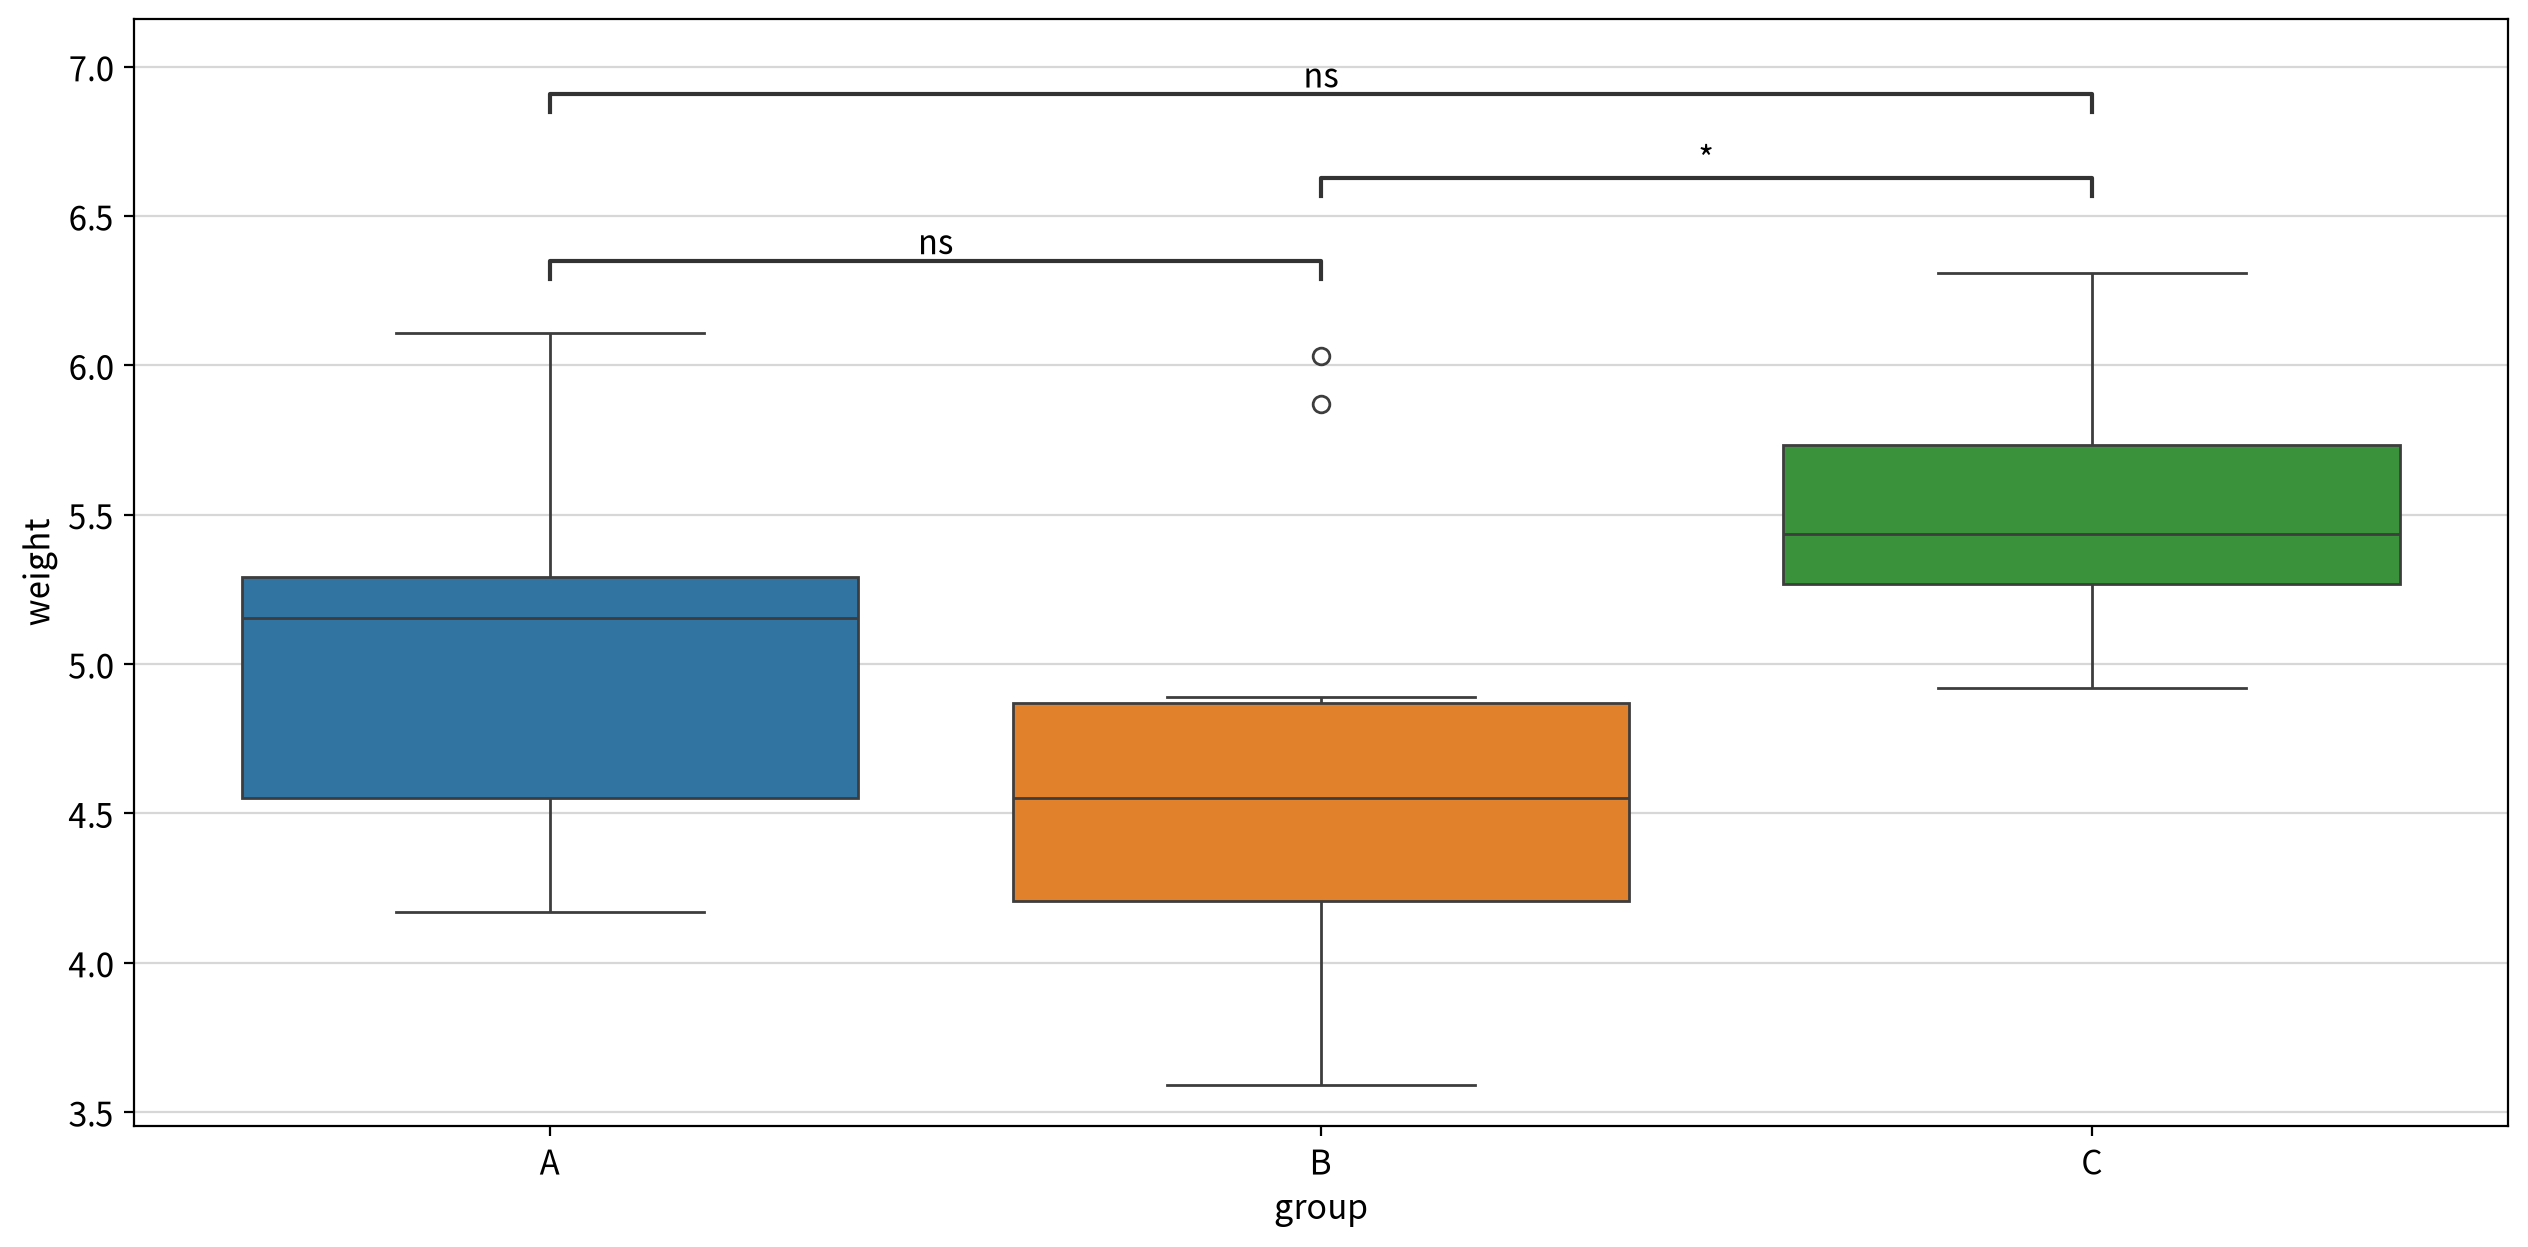

,test,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,significant,effect_size
0,Tukey HSD,A,B,5.032,4.661,0.371,0.279,1.331,0.391,0.510,False,Medium
1,Tukey HSD,A,C,5.032,5.526,-0.494,0.279,-1.772,0.198,-0.914,False,Large
2,Tukey HSD,B,C,4.661,5.526,-0.865,0.279,-3.103,0.012,-1.289,True,Large


In [9]:
my_stats.posthoc_oneway(origin, y='weight', between='group')

## # 연습문제 

### 01. 

In [10]:
origin = load_data("reading")   
origin.head()

📚 유아들을 대상으로 세 가지 읽는 방법을 비교,실험하여 얻은 독서평가 점수 데이터 (출처: 방송통신대학교 통계학개론)


,독서방법,점수
0,B,7.700
1,B,1.500
2,B,4.300
3,B,5.400
4,B,4.300


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

B vs. D: Custom statistical test, P_val:3.400e-01
D vs. G: Custom statistical test, P_val:4.031e-04
B vs. G: Custom statistical test, P_val:8.764e-05


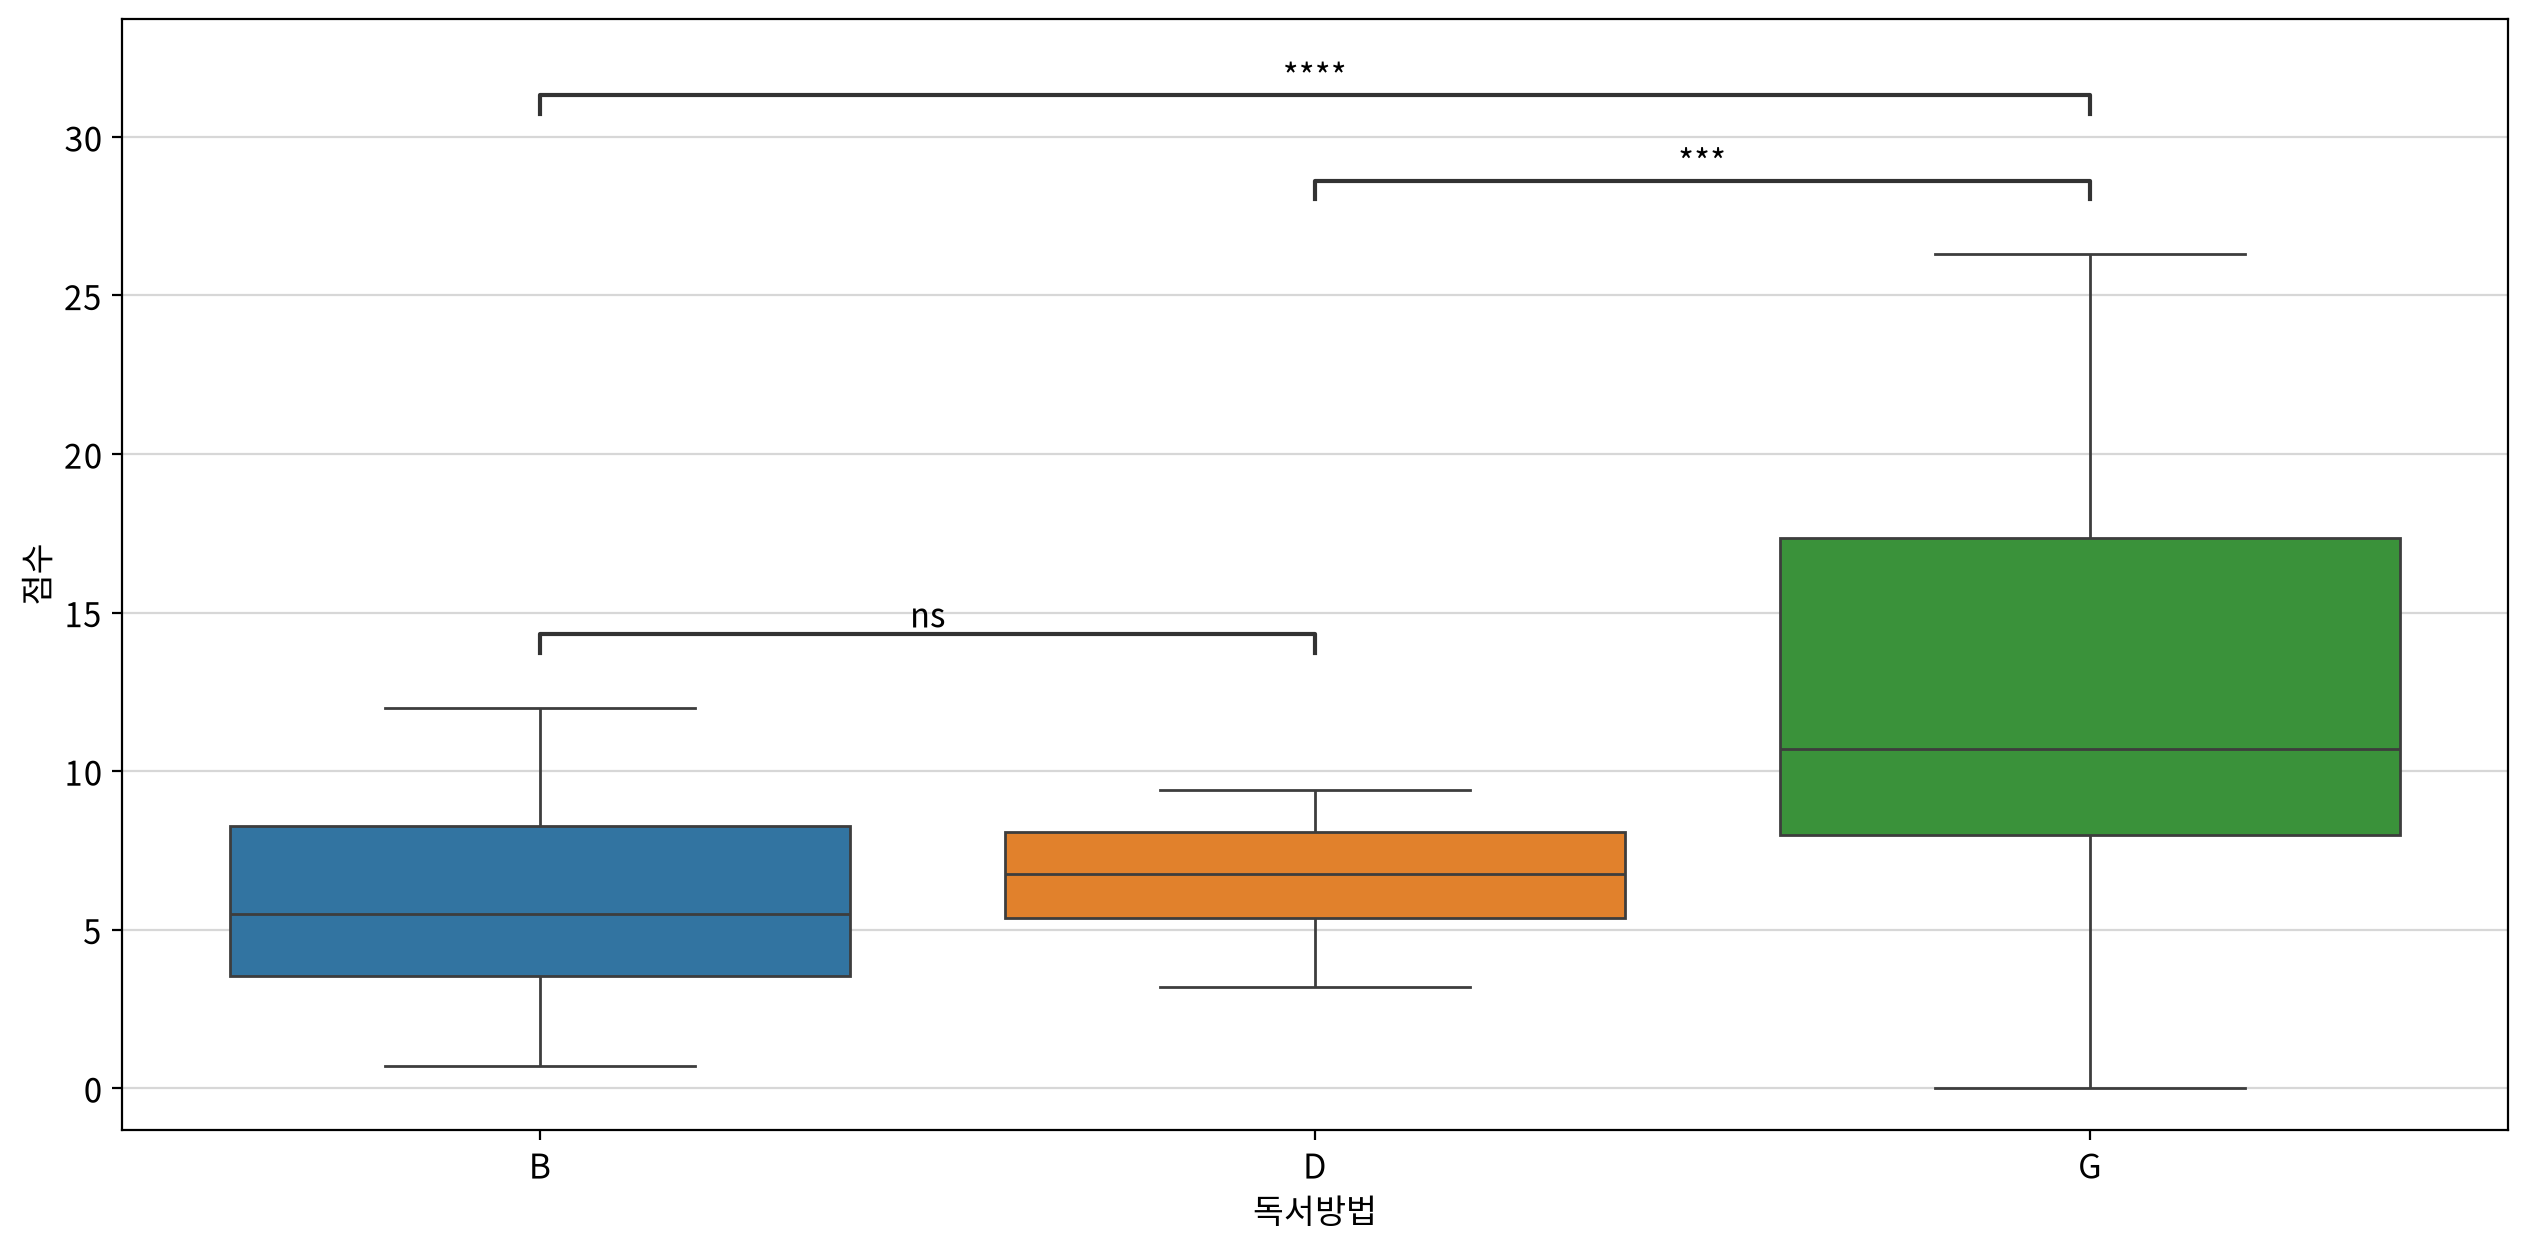

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,B,D,5.732,6.693,-0.961,0.677,-1.421,40.563,0.340,-0.376,False,Small
1,Games-Howell,B,G,5.732,12.531,-6.799,1.457,-4.666,42.964,0.000,-1.137,True,Large
2,Games-Howell,D,G,6.693,12.531,-5.838,1.363,-4.284,34.361,0.000,-1.044,True,Large


In [11]:
my_stats.posthoc_oneway(origin, y='점수', between='독서방법')

In [12]:
aov = my_stats.anova_oneway(origin, y='점수', between='독서방법')
aov  # test, np2, effect_size 컬럼 확인

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,독서방법,2,48.204,10.787,0.000,0.283,Large


In [13]:
wide = my_prep.long2wide(origin[['점수', '독서방법']].dropna(),
                          hue='독서방법', values='점수')
my_stats.test_assumptions(wide, columns=list(wide.columns))

,test,statistic,p-value,result
field,,,,
B,normaltest,2.210,0.331,True
D,normaltest,2.397,0.302,True
G,normaltest,2.217,0.330,True
Bartlett,equal_var,58.099,0.000,False


### 2. 

In [14]:
origin = load_data("commercial")
origin.head()

📚 서울시의 2023년 상권에 따른 분기별 매출액과 매출건수에 대한 자료 (출처: 서울 열린데이터 광장)


,quarter,code,type,name,sales_amount,number_of_sales
0,1,3001491,관광특구,이태원 관광특구,72523644100,2496865
1,1,3001492,관광특구,명동 남대문 북창동 다동 무교동 관광특구,283332346393,10246122
2,1,3001493,관광특구,동대문패션타운 관광특구,81696730221,2880324
3,1,3001494,관광특구,종로·청계 관광특구,212062656625,4960006
4,1,3001495,관광특구,잠실 관광특구,231338386876,5995166


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

골목상권 vs. 관광특구: Custom statistical test, P_val:6.410e-09
관광특구 vs. 발달상권: Custom statistical test, P_val:7.128e-07
발달상권 vs. 전통시장: Custom statistical test, P_val:3.927e-13
골목상권 vs. 발달상권: Custom statistical test, P_val:7.272e-14
관광특구 vs. 전통시장: Custom statistical test, P_val:1.140e-08
골목상권 vs. 전통시장: Custom statistical test, P_val:0.000e+00


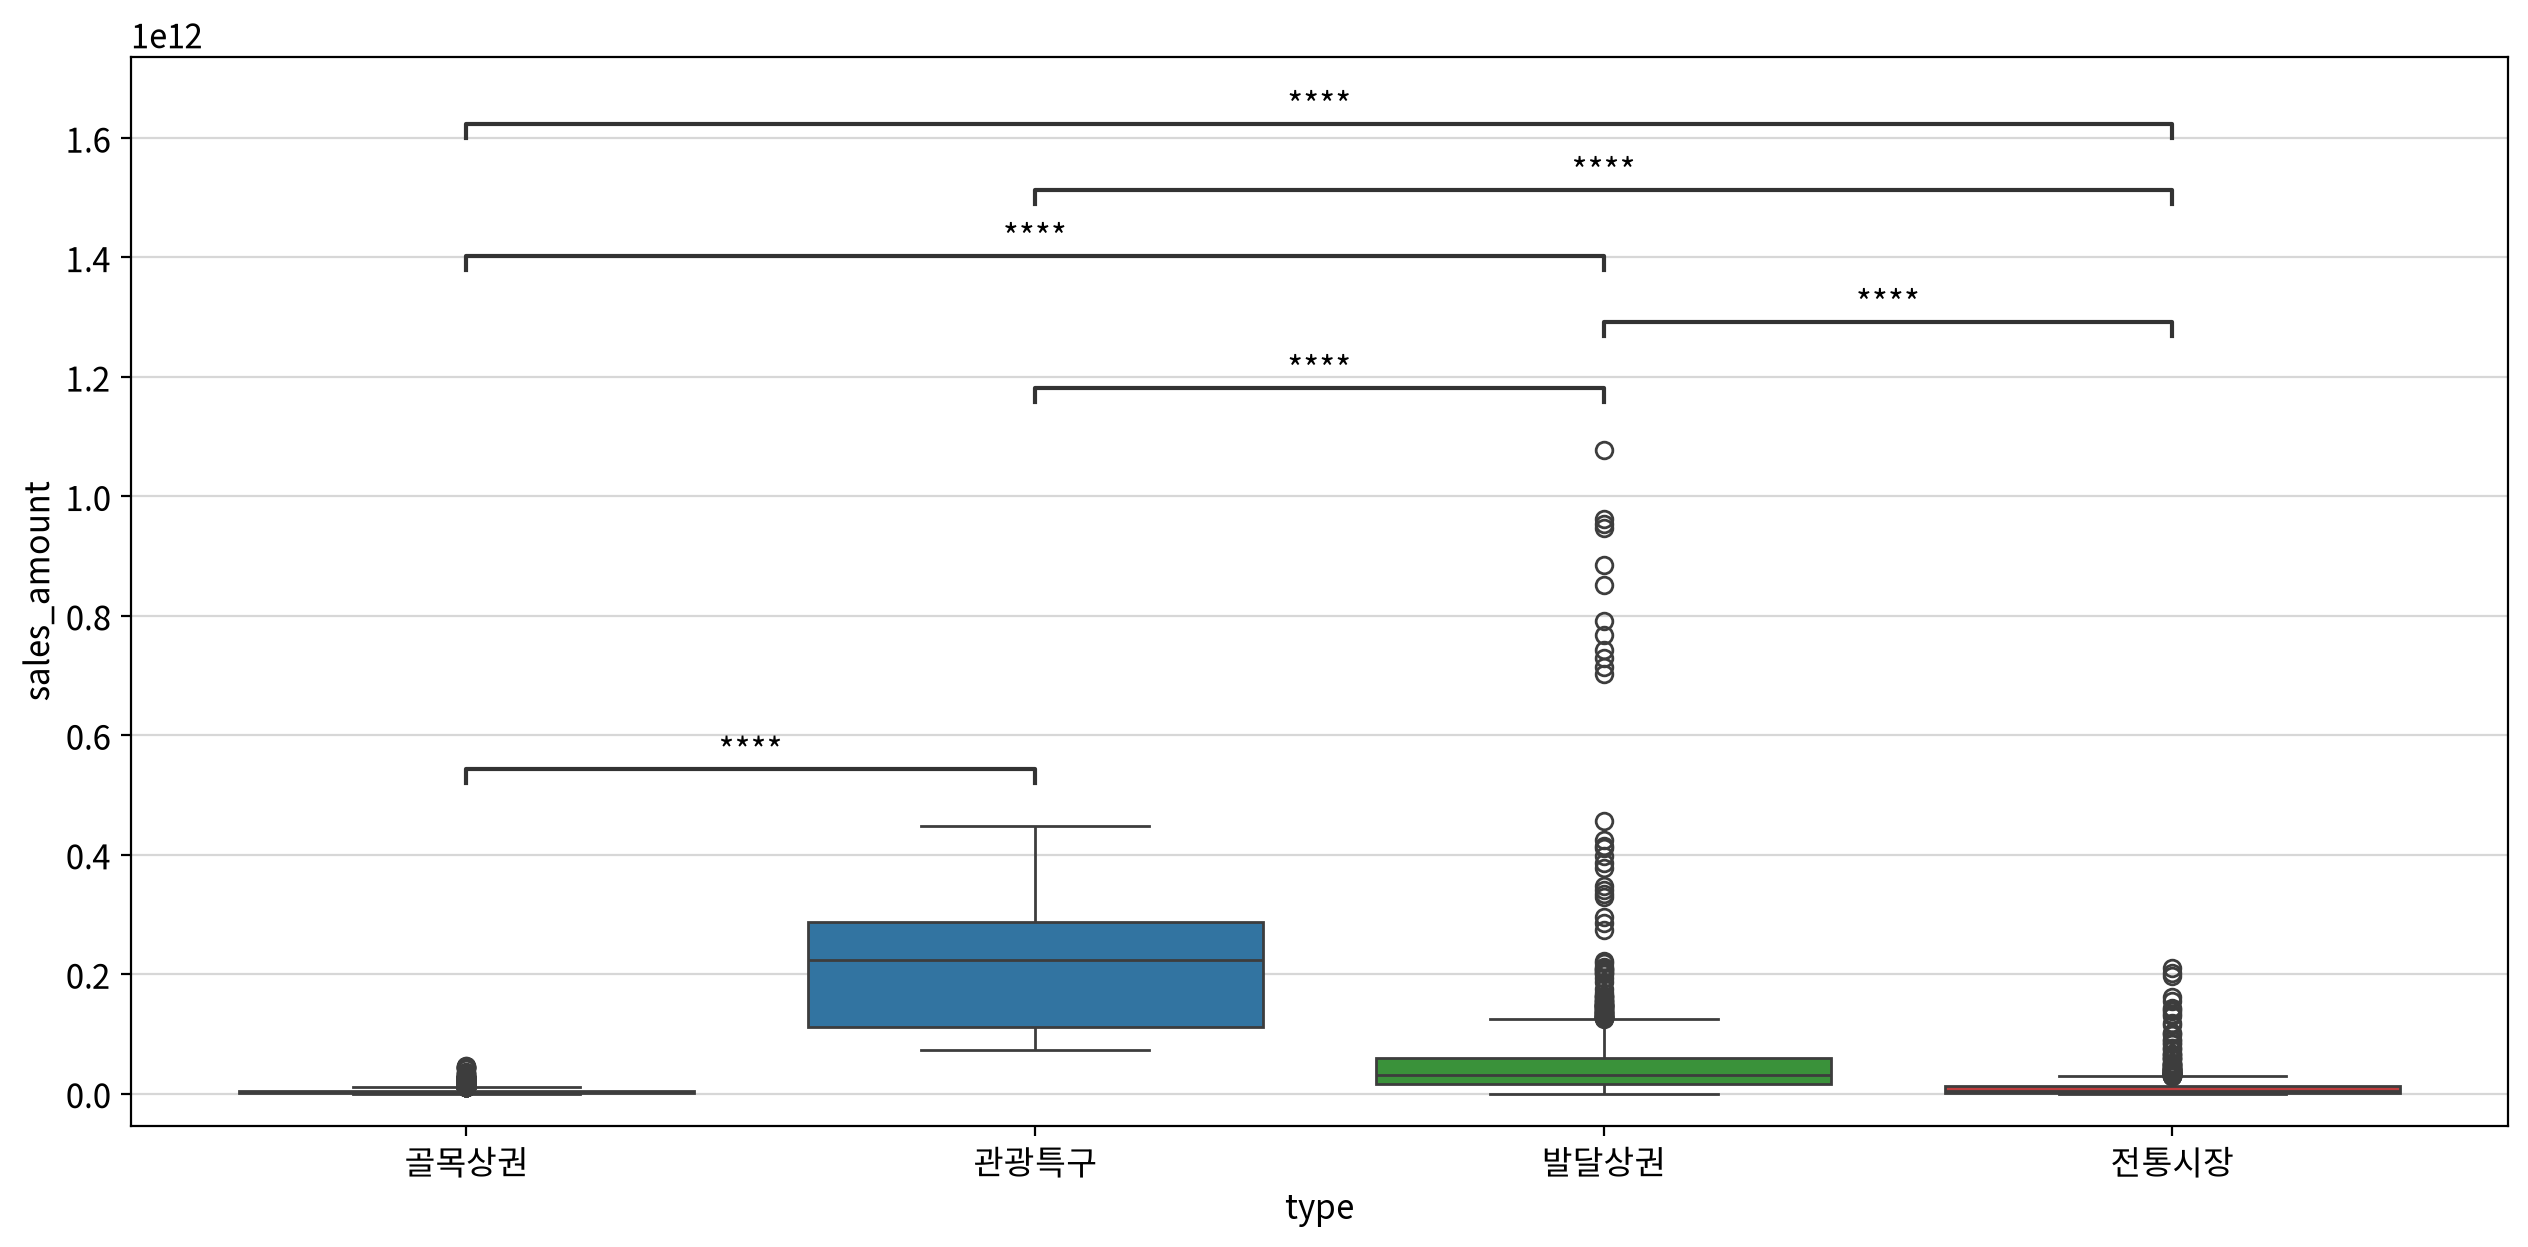

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,골목상권,관광특구,3659508698.643,228143191041.625,-224483682342.982,22892159577.450,-9.806,23.001,0.000,-23.207,True,Large
1,Games-Howell,골목상권,발달상권,3659508698.643,57063096491.533,-53403587792.891,3282877885.264,-16.267,996.055,0.000,-1.160,True,Large
2,Games-Howell,골목상권,전통시장,3659508698.643,10584197874.740,-6924689176.098,606055894.461,-11.426,1143.188,0.000,-0.679,True,Medium
3,Games-Howell,관광특구,발달상권,228143191041.625,57063096491.533,171080094550.092,23126107295.058,7.398,23.955,0.000,1.647,True,Large
4,Games-Howell,관광특구,전통시장,228143191041.625,10584197874.740,217558993166.885,22899931335.272,9.500,23.032,0.000,8.537,True,Large
5,Games-Howell,발달상권,전통시장,57063096491.533,10584197874.740,46478898616.793,3336640863.245,13.930,1061.850,0.000,0.639,True,Medium


In [15]:
my_stats.posthoc_oneway(origin, y='sales_amount', between='type')

### 3. 

In [16]:
origin = load_data("tips")
origin.head()

📚 식당 고객의 결제 금액, 팁, 성별, 흡연 여부, 요일, 시간대, 일행 규모 등 기본 정보를 담은 데이터 분석·시각화 실습용 샘플 데이터 (출처: https://www.kaggle.com/datasets/sakshisatre/tips-dataset)

field       description
----------  -------------
total_bill  총 결제 금액
tip         팁 금액
sex         성별
smoker      흡연 여부
day         방문 요일
time        방문 시간대
size        일행 규모



,total_bill,tip,sex,smoker,day,time,size
0,16.990,1.010,Female,No,Sun,Dinner,2
1,10.340,1.660,Male,No,Sun,Dinner,3
2,21.010,3.500,Male,No,Sun,Dinner,3
3,23.680,3.310,Male,No,Sun,Dinner,2
4,24.590,3.610,Female,No,Sun,Dinner,4


In [17]:
my_stats.anova_oneway(origin, y='total_bill', between='day')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,anova,day,3,240,2.767,0.042,0.033,Small


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Fri vs. Sat: Custom statistical test, P_val:4.541e-01
Sat vs. Sun: Custom statistical test, P_val:8.968e-01
Sun vs. Thur: Custom statistical test, P_val:6.678e-02
Fri vs. Sun: Custom statistical test, P_val:2.371e-01
Sat vs. Thur: Custom statistical test, P_val:2.374e-01
Fri vs. Thur: Custom statistical test, P_val:9.957e-01


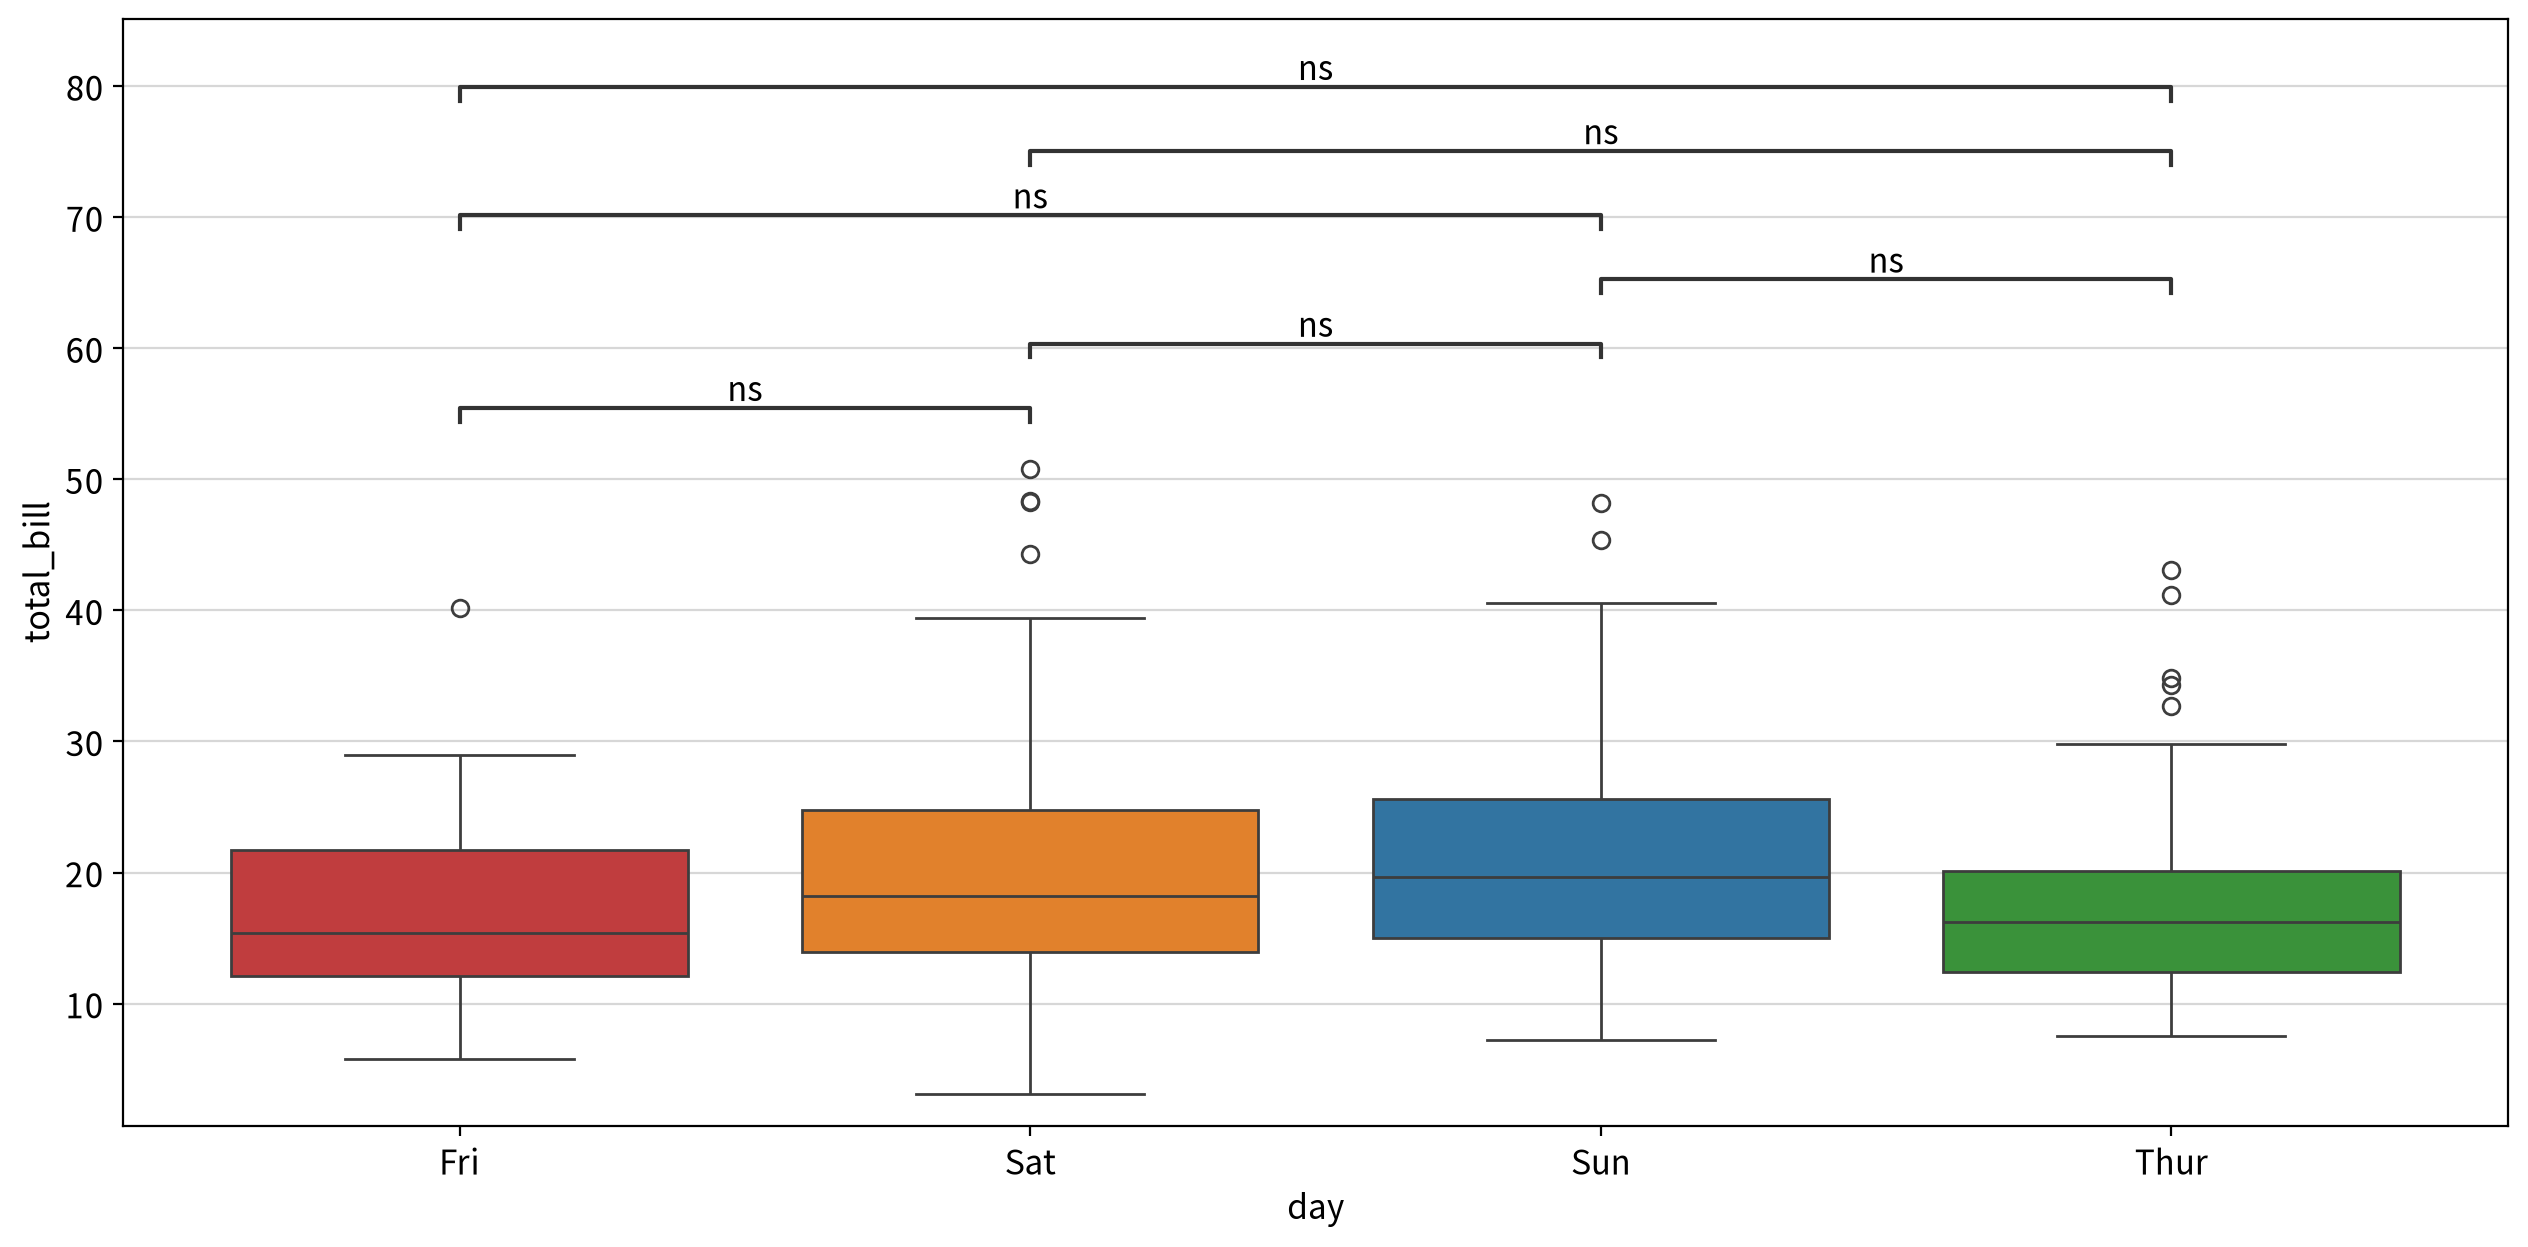

,test,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,significant,effect_size
0,Tukey HSD,Fri,Sat,17.152,20.441,-3.290,2.230,-1.475,0.454,-0.352,False,Small
1,Tukey HSD,Fri,Sun,17.152,21.410,-4.258,2.259,-1.885,0.237,-0.484,False,Small
2,Tukey HSD,Fri,Thur,17.152,17.683,-0.531,2.309,-0.230,0.996,-0.066,False,Negligible
3,Tukey HSD,Sat,Sun,20.441,21.410,-0.969,1.383,-0.700,0.897,-0.105,False,Negligible
4,Tukey HSD,Sat,Thur,20.441,17.683,2.759,1.464,1.885,0.237,0.310,False,Small
5,Tukey HSD,Sun,Thur,21.410,17.683,3.727,1.507,2.473,0.067,0.440,False,Small


In [18]:
my_stats.posthoc_oneway(origin, y='total_bill', between='day')

### 4. 

In [19]:
origin = load_data("tomato")
origin.head()

📚 효소 성분의 비료가 효소 함량이 증가함에 따라 토마토 모종 포기의 성장에 어떤 영향을 주는지에 대한 실험 결과 (출처: 방송통신대학교 통계학 개론)


,효소함량,모종성장
0,0,9.500
1,0,10.000
2,0,10.700
3,0,9.000
4,0,12.400


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 100: Custom statistical test, P_val:7.229e-10
100 vs. 1000: Custom statistical test, P_val:9.517e-07
0 vs. 1000: Custom statistical test, P_val:2.220e-15


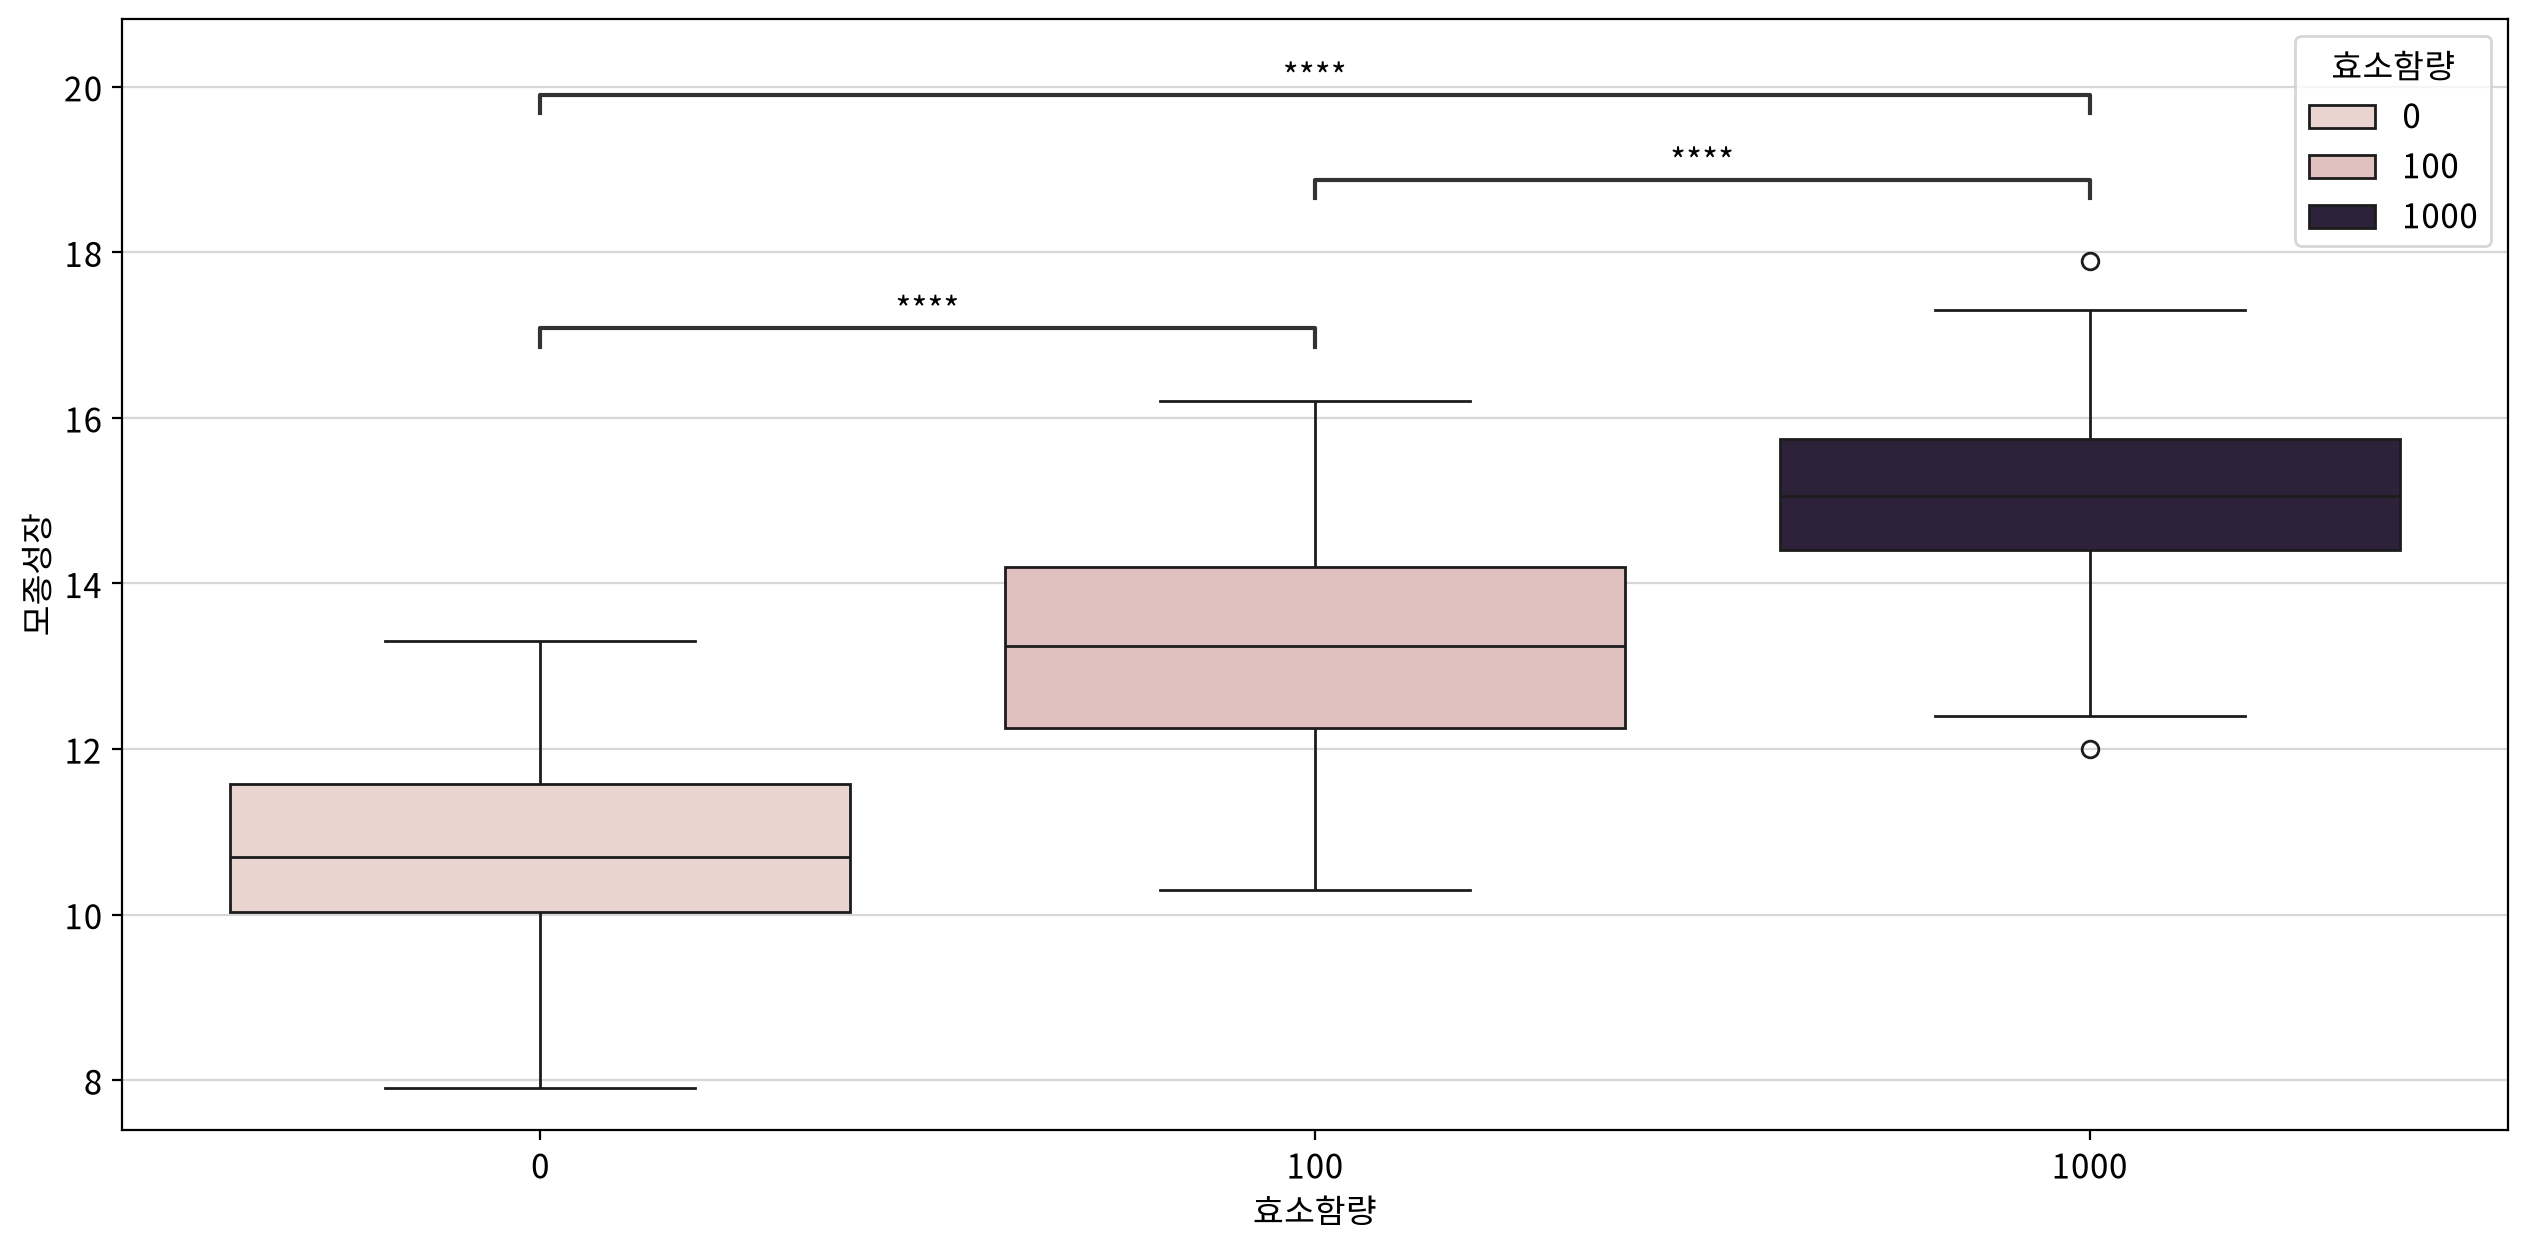

,test,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,significant,effect_size
0,Tukey HSD,0,100,10.753,13.180,-2.427,0.339,-7.162,0.000,-1.868,True,Large
1,Tukey HSD,0,1000,10.753,15.057,-4.303,0.339,-12.701,0.000,-3.316,True,Large
2,Tukey HSD,100,1000,13.180,15.057,-1.877,0.339,-5.539,0.000,-1.351,True,Large


In [20]:
my_stats.posthoc_oneway(origin, y='모종성장', between='효소함량')